# Data analysis for the MS3.08 Introduction to Computer Controlled Experiments

## The data analysis is conducted by **Angze Li** and **Devan Hu**.


# 0. Aim of the analysis

1. The selection of 0.1 s as the optimal delay time was justified for the whole experiment.

2. The **turn-on voltage** for each LED was determined from the first derivative of the I–V characteristics using *Origin* (not performed in this notebook). Experimental uncertainties were assessed using errorbar analysis based on repeated measurements.

3. The **effect of temperature** on the turn-on voltage was investigated by comparing room-temperature data with measurements taken under liquid-nitrogen (LN2) cooling. Finally, the I–V characteristics were analysed on a semi-logarithmic scale and fitted using the **Shockley diode equation** (shown below) to examine diode behaviour above the turn-on region. The **apparent ideality factors** were extracted from the linear fits performed and compared between rt and LN2-cooled LEDs.

$$
I = I_0\left(e^{\frac{qV}{nkT}} - 1\right)
$$

In [1]:
#note: all the libraries were imported here

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter, LogFormatterMathtext

In [235]:
#note: all the variables were pre-defined here

cols = {
    "Red LED": "Red",
    "Yellow LED": "Yellow",
    "Green LED": "Green",
    "Blue LED": "Blue",
    "White LED": "White",
}

colors = {
    "Resistor": "black",
    "Blue LED": "blue",
    "Green LED": "green",
    "Red LED": "red",
    "Yellow LED": "gold",
    "White LED": "grey",
}

colors_rt  = {"Red LED":"#ff6f6f","Yellow LED":"#ffd54f","Green LED":"#66bb6a","Blue LED":"#64b5f6","White LED":"#bdbdbd"}
colors_ln2 = {"Red LED":"#c62828","Yellow LED":"#f9a825","Green LED":"#2e7d32","Blue LED":"#1565c0","White LED":"#424242"}

full_labels = ["Red LED", "Yellow LED", "Green LED", "Blue LED", "White LED"]

paths = {
    "Resistor": "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/raw data_finalised/4_Resistor/resistor_repeats5_20260122_201801.csv",
    "Yellow LED": "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/raw data_finalised/5_LED_Colours/Yellow_LED/Yellow_LED_repeats5_20260123_104738.csv",
    "White LED":  "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/raw data_finalised/5_LED_Colours/White_LED/White_LED_repeats5_20260123_104738.csv",
    "Red LED":    "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/raw data_finalised/5_LED_Colours/Red_LED/Red_LED_repeats5_20260123_104738.csv",
    "Green LED":  "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/raw data_finalised/5_LED_Colours/Green_LED/Green_LED_repeats5_20260123_104738.csv",
    "Blue LED":   "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/raw data_finalised/5_LED_Colours/Blue_LED/Blue_LED_repeats5_20260123_104738.csv",
}

ln2_paths = {
    "Red LED":    "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/extension work/LN2/red_LiquidN2_cooled.csv",
    "Yellow LED": "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/extension work/LN2/yellow_LiquidN2_cooled.csv",
    "Green LED":  "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/extension work/LN2/green_LiquidN2_cooled.csv",
    "Blue LED":   "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/extension work/LN2/blue_LiquidN2_cooled.csv",
    "White LED":  "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260123/extension work/LN2/white_LiquidN2_cooled.csv",
}

error_bar_datapath = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/raw data_finalised/Turn-on Voltages.csv"

In [251]:
#note: all the functions were pre-defined here

##the function below saves the figure plotted to the corresponding folder
FIG_DIR = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures"
os.makedirs(FIG_DIR, exist_ok=True)
def fig_path(filename):
    return os.path.join(FIG_DIR, filename) 

##the two functions below loads the I-V data from csv file
def load_iv_from_csv(path, V_col=0, I_col=6):
    df = pd.read_csv(path)
    I = pd.to_numeric(df.iloc[:, I_col], errors="coerce").to_numpy()
    V = pd.to_numeric(df.iloc[:, V_col], errors="coerce").to_numpy()

    m = np.isfinite(I) & np.isfinite(V)
    I, V = I[m], V[m]

    order = np.argsort(V)
    V, I = V[order], I[order]
    return V, I

def load_ln2_csv(path, V_col=0, I_col=1, skiprows=1):
    arr = np.loadtxt(path, delimiter=",", skiprows=skiprows)
    V, I = arr[:, V_col], arr[:, I_col]
    m = np.isfinite(V) & np.isfinite(I)
    V, I = V[m], I[m]
    idx = np.argsort(V)
    return V[idx], I[idx]

##the function below performs linear fit to the data 
def linear_fit_with_r2(x, y):
    m, c = np.polyfit(x, y, 1)
    y_fit = m * x + c

    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    R2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return m, c, y_fit, R2

##the two functions below calculates ideality factor n from the slope of log(I)-V plot at rt and cooled by LN2
def rt_n_calculator(slope_list):
    return 1/(np.array(slope_list)*0.0249*np.log(10))

def ln2_n_calculator(slope_list):
    return 1/(np.array(slope_list)*0.00664*np.log(10))    

##the function below sets the size of the figure and the spine of the box
def init_ax(figsize=(8, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    return fig, ax

##the function below sets the "norm" for conducting a line plot
def finalize_plot(
    ax,
    xlabel,
    ylabel,
    title,
    out_path,
    ylim=None,
    legend=True,
    legend_loc="upper left",
    legend_size=12,
    dpi=600
):
    ax.set_xlabel(xlabel, fontsize=22, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=22, fontweight="bold")
    ax.set_title(title, fontsize=20, fontweight="bold")

    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")

    if ylim is not None:
        ax.set_ylim(*ylim)
        
    if legend:
        leg = ax.legend(
            prop={"size": legend_size, "weight": "bold"},
            loc=legend_loc,
            frameon=True,
            fancybox=True
        )
        leg.get_frame().set_alpha(0.85)
        leg.get_frame().set_edgecolor("black")
        leg.get_frame().set_linewidth(1.2)

    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi)
    plt.show()

##the function below sets the "norm" for conducting a barplot with one bar for each coloured LED
def barplot_with_error(
    labels,
    means,
    errors,
    out_path,
    *,
    colors=None,
    xlabel="",
    ylabel="",
    title="",
    ylim_pad=0.12,
    figsize=(8, 6),
    capsize=6
):

    x = np.arange(len(labels))

    plt.figure(figsize=figsize)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

    bars = ax.bar(
        x, means,
        yerr=errors,
        capsize=capsize,
        color=colors,
        edgecolor="k",
        linewidth=1.2
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=14, fontweight="bold")
    ax.tick_params(axis="y", labelsize=14)
    for t in ax.get_yticklabels():
        t.set_fontweight("bold")

    ax.set_xlabel(xlabel, fontsize=22, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=22, fontweight="bold")
    ax.set_title(title, fontsize=22, fontweight="bold")

    ymax = max(m + s for m, s in zip(means, errors)) + ylim_pad
    ymin = min(m - s for m, s in zip(means, errors)) - ylim_pad
    ax.set_ylim(max(0, ymin), ymax)

    ax.grid(axis="y", alpha=0.3)

    for bar, m, s in zip(bars, means, errors):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + s + 0.02,
            f"{m:.3f} ± {s:.3f} V",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig(out_path, dpi=600)
    plt.show()

##the function below sets the "norm" for conducting a grouped barplot with two bars for each coloured LED
def grouped_barplot_two_conditions(
    labels,
    y1, y2,
    *,
    colors1=None, colors2=None,
    label1="Condition 1", label2="Condition 2",
    xlabel="", ylabel="", title="",
    out_path=None,
    note=None, note_pos=(0.015, 0.83),
    logy=False,
    annotate_fmt="{:.3f}",
    annotate_mult=1.08,    
    annotate_add=0.02,     
    grid_alpha=0.3,
    ylim=None,
    figsize=(10, 6),
    w=0.36
):
    y1 = np.asarray(y1, dtype=float)
    y2 = np.asarray(y2, dtype=float)
    if len(labels) != len(y1) or len(labels) != len(y2):
        raise ValueError("labels, y1, y2 must have the same length")

    fig, ax = init_ax(figsize=figsize)
    x = np.arange(len(labels))

    b1 = ax.bar(
        x - w/2, y1, w,
        color=colors1, edgecolor="k", linewidth=1.2, label=label1
    )
    b2 = ax.bar(
        x + w/2, y2, w,
        color=colors2, edgecolor="k", linewidth=1.2, label=label2
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=14, fontweight="bold")

    if logy:
        ax.set_yscale("log")
        ax.grid(axis="y", which="both", alpha=grid_alpha)
    else:
        ax.grid(axis="y", alpha=grid_alpha)

    if note:
        ax.text(
            note_pos[0], note_pos[1], note,
            transform=ax.transAxes, fontsize=13, fontweight="bold", va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.85)
        )

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if not np.isfinite(h):
            continue
        ytxt = (h * annotate_mult) if logy else (h + annotate_add)
        ax.text(
            bar.get_x() + bar.get_width()/2, ytxt,
            annotate_fmt.format(h),
            ha="center", va="bottom",
            fontsize=11 if logy else 12, fontweight="bold"
        )

    if ylim is None and logy:
        all_y = np.r_[y1, y2]
        all_y = all_y[np.isfinite(all_y) & (all_y > 0)]
        if all_y.size:
            ymin = max(0.5, all_y.min() / 1.5)
            ymax = all_y.max() * 1.5
            ylim = (ymin, ymax)

    finalize_plot(
        ax,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        out_path=out_path,
        legend=True,
        legend_loc="upper left",
        legend_size=13,
        ylim=ylim
    )
    return fig, ax

##the function below sets the "norm" for log(I)-V plot with linear fit
def plot_semilog_iv_with_fit(
    labels,
    path_map,
    V_on_map,
    *,
    loader,                
    title,
    out_path,
    ylim=None,
    legend_loc="lower left",
    legend_size=10
):
    fig, ax = init_ax()
    slopes = []

    for led in labels:
        V, I = loader(path_map[led])

        mask = (I > 0) & (V >= V_on_map[led])
        Vp, Ip = V[mask], I[mask]

        ax.semilogy(Vp, Ip, "o", ms=5, color=colors[led])

        logI = np.log10(Ip)
        a, b, logI_fit, R2 = linear_fit_with_r2(Vp, logI)
        ax.semilogy(Vp, 10**logI_fit, "-", lw=2.2, color=colors[led],
                    label=f"{led}, $R^2$={R2:.4f}")

        slopes.append(round(a, 5))

    format_logy_axis(ax)

    finalize_plot(
        ax,
        xlabel="Voltage / V",
        ylabel="Current / mA (log scale)",
        title=title,
        out_path=out_path,
        legend=True,
        legend_loc=legend_loc,
        legend_size=legend_size,
        ylim=ylim
    )
    return slopes

##the function below ensures the colours are correctly mapped
def colors_for(labels, cmap_dict):
    return [cmap_dict[l] for l in labels]

##the function below sets up the yticks for log-y scale
def format_logy_axis(ax):
    ax.tick_params(axis="y", which="major", length=8, width=1.6)
    ax.tick_params(axis="y", which="minor", length=4, width=1.2)
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_formatter(NullFormatter())

# 1. Delay Time

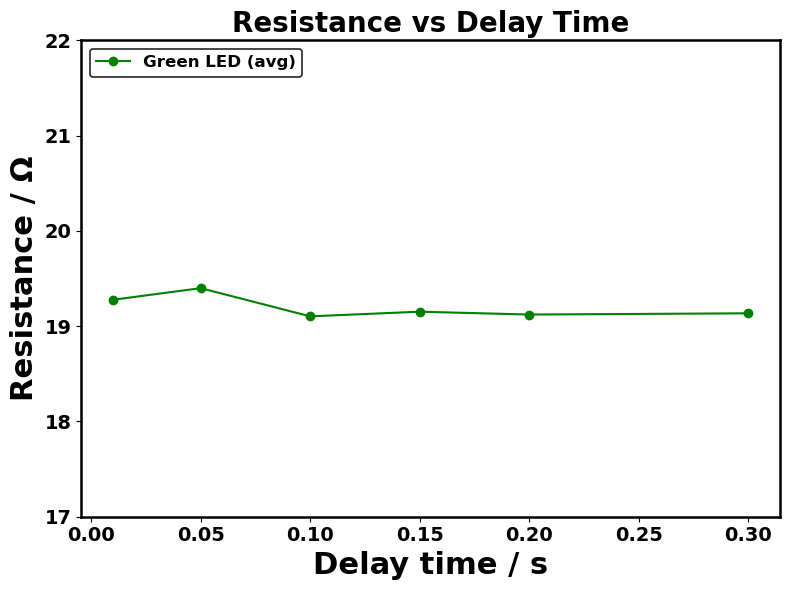

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Green_LED_Resistance_vs_Delay_Time.png


In [237]:
#note: delay time tested using green LED. Here the data was manually imported.

delay_time_array = np.array([0.01, 0.05, 0.1, 0.15, 0.2, 0.3])
resistance_delay_time_array = np.array([19.277, 19.399, 19.103, 19.152, 19.122, 19.135])

out_path = fig_path("Green_LED_Resistance_vs_Delay_Time.png")

fig, ax = init_ax()

ax.plot(
    delay_time_array,
    resistance_delay_time_array,
    "o-",
    color="green",
    label="Green LED (avg)"
)

finalize_plot(
    ax,
    xlabel="Delay time / s",
    ylabel="Resistance / Ω",
    title="Resistance vs Delay Time",
    ylim=(17,22),
    out_path=out_path
)

print(f"Saved figure → {out_path}")

# 2. Average performance of I-V figures of LEDs and the resistor

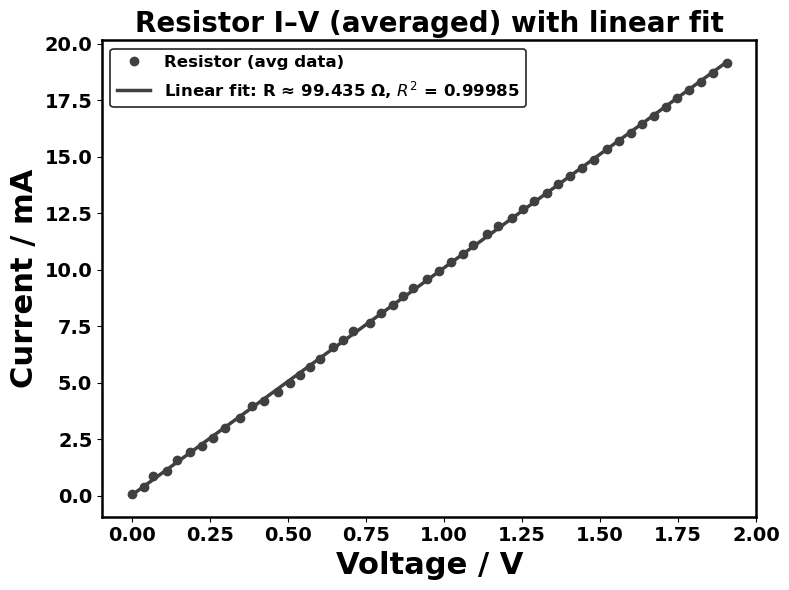

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Resistor_avg_I-V_linear_fit.png


In [238]:
#note: averaged I–V of resistor with lienar fit

res_path = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/raw data_finalised/4_Resistor/resistor_repeats5_20260122_201801.csv"
out_path = fig_path("Resistor_avg_I-V_linear_fit.png")

V, I = load_iv_from_csv(res_path, V_col=0, I_col=6)

m_fit, c_fit, I_fit, R2 = linear_fit_with_r2(V, I)

R_ohm = 1000 / m_fit

fig, ax = init_ax()

ax.plot(V, I, "o", color="0.25", label="Resistor (avg data)")
ax.plot(
    V, I_fit, "-",
    linewidth=2.5, color="0.25",
    label=f"Linear fit: R ≈ {R_ohm:.3f} Ω, $R^2$ = {R2:.5f}"
)

finalize_plot(
    ax,
    xlabel="Voltage / V",
    ylabel="Current / mA",
    title="Resistor I–V (averaged) with linear fit",
    out_path=out_path,
    legend_size=12
)

print(f"Saved figure → {out_path}")

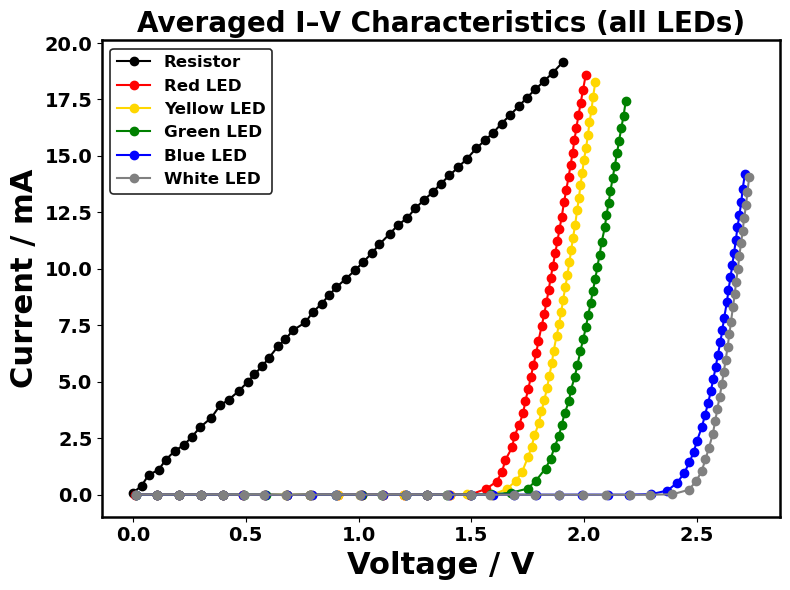

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Averaged I-V Characteristics_allLEDs.png


In [239]:
#note: averaged I–V characteristics of resistor and LEDs

fig, ax = init_ax()
out_path = fig_path("Averaged I-V Characteristics_allLEDs.png")

plot_order = ["Resistor", "Red LED", "Yellow LED", "Green LED", "Blue LED", "White LED"]

for name in plot_order:
    path = paths[name]
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found for {name}:\n{path}")

    V, I = load_iv_from_csv(path, V_col=0, I_col=6)
    ax.plot(V, I, "o-", label=name, color=colors.get(name))

finalize_plot(
    ax,
    xlabel="Voltage / V",
    ylabel="Current / mA",
    title="Averaged I–V Characteristics (all LEDs)",
    out_path=out_path,
    legend=True,
    legend_loc="upper left",
    legend_size=12
)

print(f"Saved figure → {out_path}")

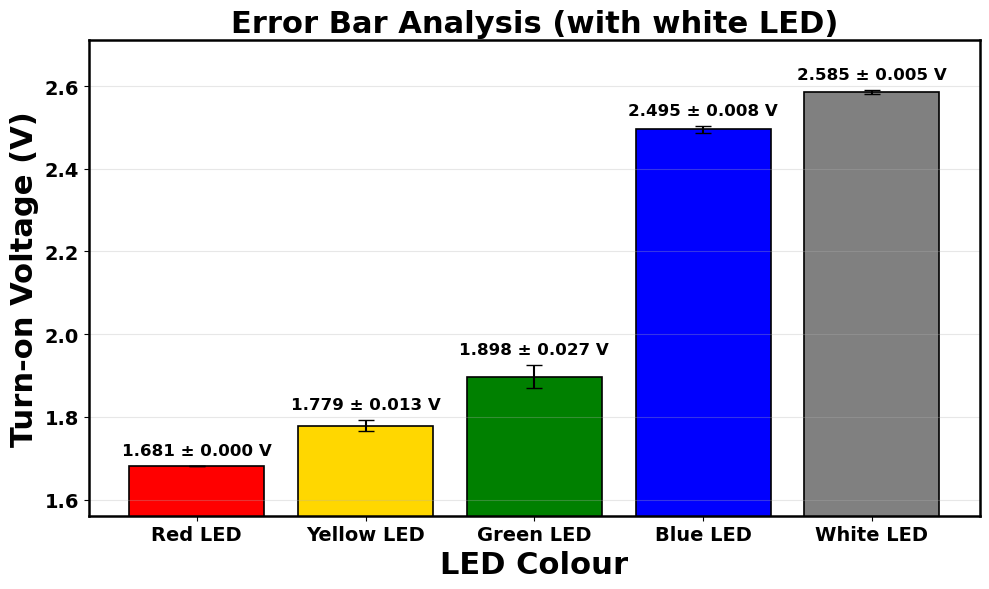

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Turn-on Voltage Mean and SD (with White).png


In [240]:
#note: error bar plot for LEDs 

df = pd.read_csv(error_bar_datapath)
data = [df[cols[lbl]].dropna().astype(float).to_numpy() for lbl in full_labels]
out_path = fig_path("Turn-on Voltage Mean and SD (with White).png")

barplot_with_error(
    labels=full_labels,
    means=[a.mean() for a in data],
    errors=[a.std(ddof=1) for a in data],
    colors=[colors[lbl] for lbl in labels],
    xlabel="LED Colour",
    ylabel="Turn-on Voltage (V)",
    title="Error Bar Analysis (with white LED)",
    figsize=(10, 6),
    out_path=out_path)

print(f"Saved figure → {out_path}")

# 3. Extension - Liquid N2 (LN2) cooled LED

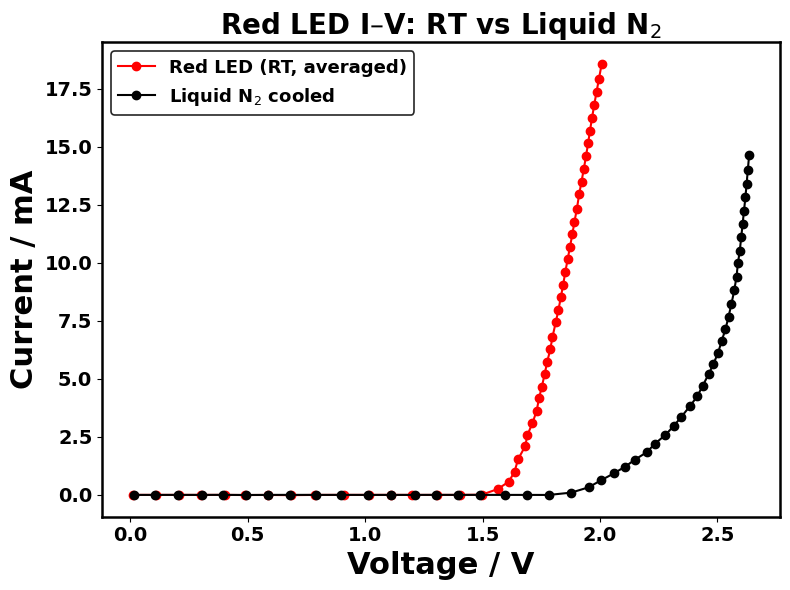

Saved → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Red_LED_IV_RT_vs_LN2.png


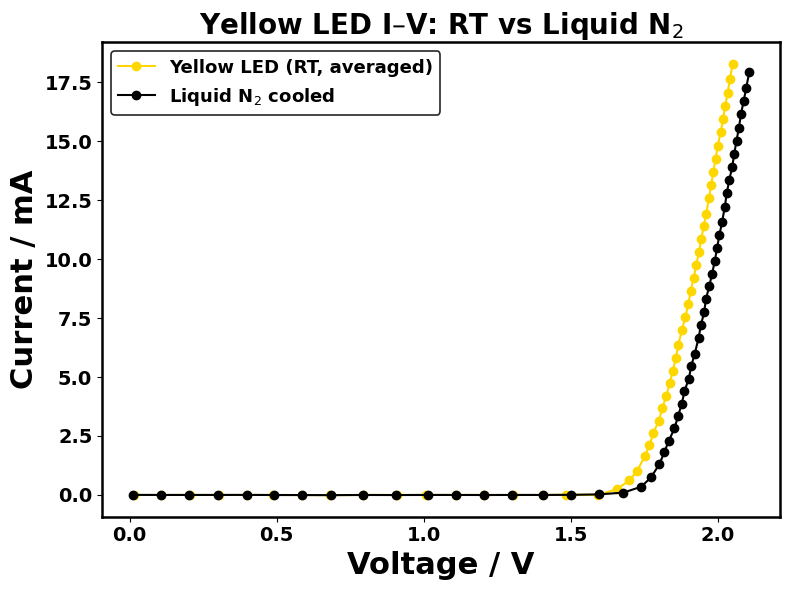

Saved → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Yellow_LED_IV_RT_vs_LN2.png


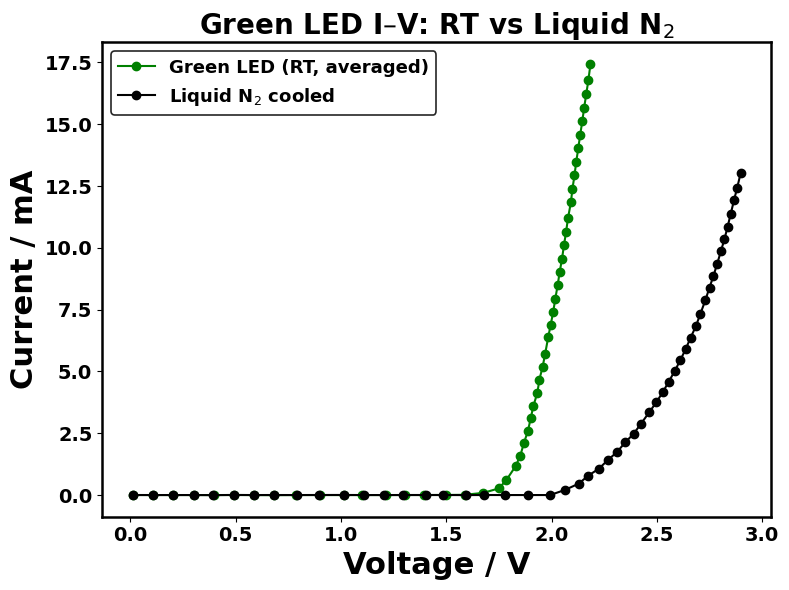

Saved → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Green_LED_IV_RT_vs_LN2.png


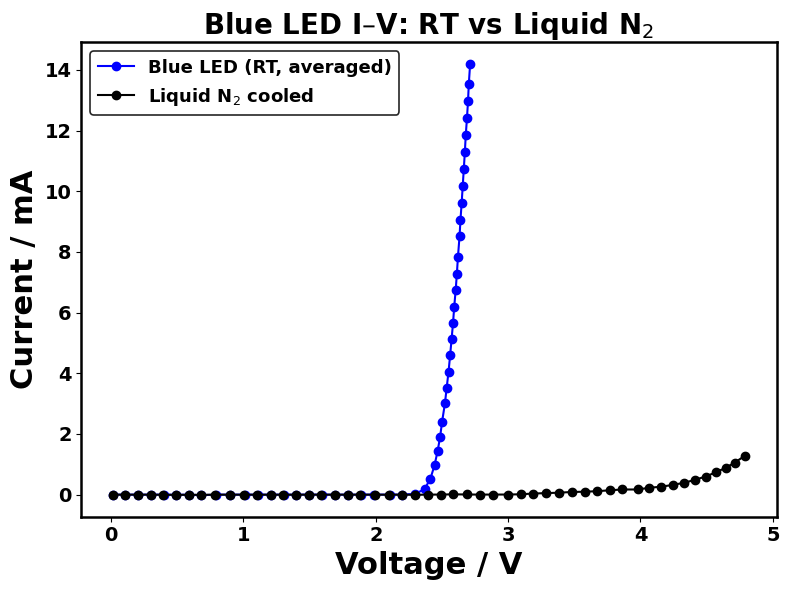

Saved → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Blue_LED_IV_RT_vs_LN2.png


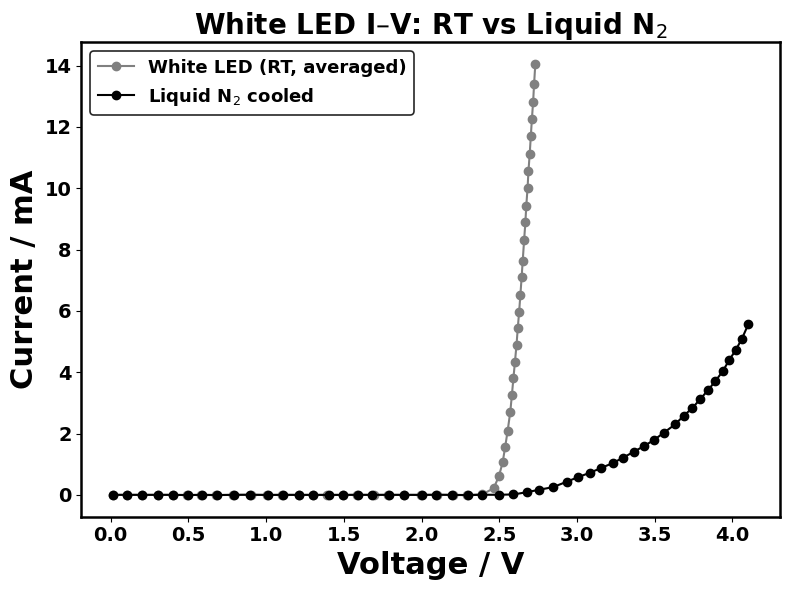

Saved → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/White_LED_IV_RT_vs_LN2.png


In [241]:
#note: I-V plot: RT vs LN2-cooled LED

for led in full_labels:
    rt_file  = paths[led]
    ln2_file = ln2_paths[led]

    V_rt,  I_rt  = load_iv_from_csv(rt_file, V_col=0, I_col=-1)
    V_ln2, I_ln2 = load_ln2_csv(ln2_file) 

    fig, ax = init_ax(figsize=(8, 6))

    ax.plot(V_rt,  I_rt,  "o-", color=colors[led], label=f"{led} (RT, averaged)")
    ax.plot(V_ln2, I_ln2, "o-", color="black",     label="Liquid N$_2$ cooled")

    out_path = fig_path(f"{led.replace(' ', '_')}_IV_RT_vs_LN2.png")
    finalize_plot(
        ax,
        xlabel="Voltage / V",
        ylabel="Current / mA",
        title=f"{led} I–V: RT vs Liquid N$_2$",
        out_path=out_path,
        legend=True,
        legend_size=13
    )

    print(f"Saved → {out_path}")

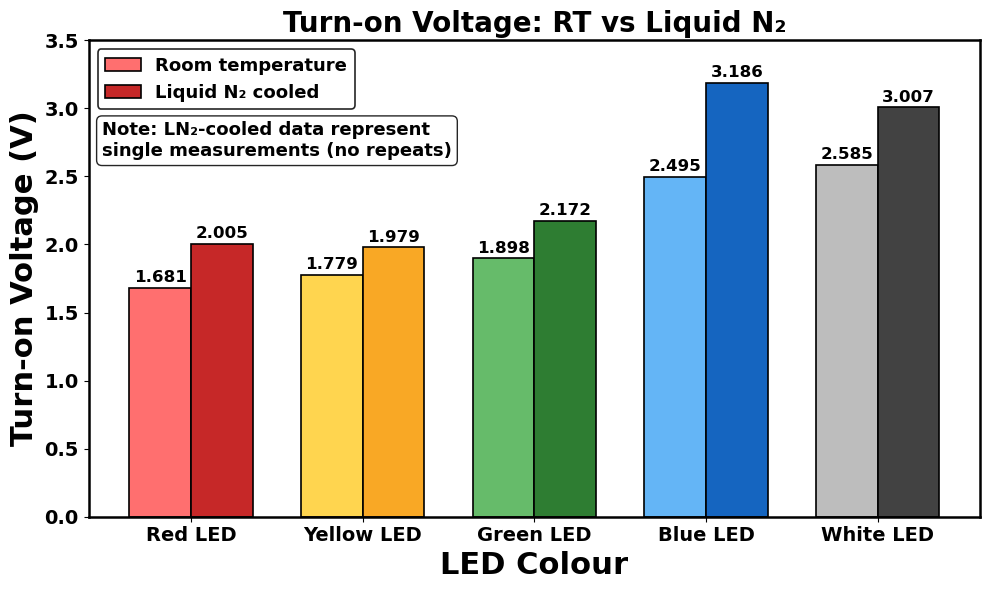

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Turn-on Voltage RT vs LN2.png


In [242]:
#note: turn-on voltage: RT vs LN2

rt_csv  = error_bar_datapath
ln2_csv = "/Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/extension work/LN2/turn_on_voltages_LN2_cooled.csv"

df_rt  = pd.read_csv(rt_csv)
df_ln2 = pd.read_csv(ln2_csv)

labels   = full_labels
rt_means = [df_rt[cols[l]].dropna().astype(float).mean() for l in labels]
ln2_vals = [df_ln2[cols[l]].dropna().astype(float).iloc[0] for l in labels]

out_path = fig_path("Turn-on Voltage RT vs LN2.png")
grouped_barplot_two_conditions(
    labels,
    rt_means, ln2_vals,
    colors1=colors_for(labels, colors_rt),
    colors2=colors_for(labels, colors_ln2),
    label1="Room temperature",
    label2="Liquid N₂ cooled",
    xlabel="LED Colour",
    ylabel="Turn-on Voltage (V)",
    title="Turn-on Voltage: RT vs Liquid N₂",
    note="Note: LN₂-cooled data represent\nsingle measurements (no repeats)",
    annotate_fmt="{:.3f}",
    logy=False,
    ylim=(0, 3.5),
    grid_alpha=0, 
    out_path=out_path
)
print(f"Saved figure → {out_path}")

# 4. Semi-log scale plot

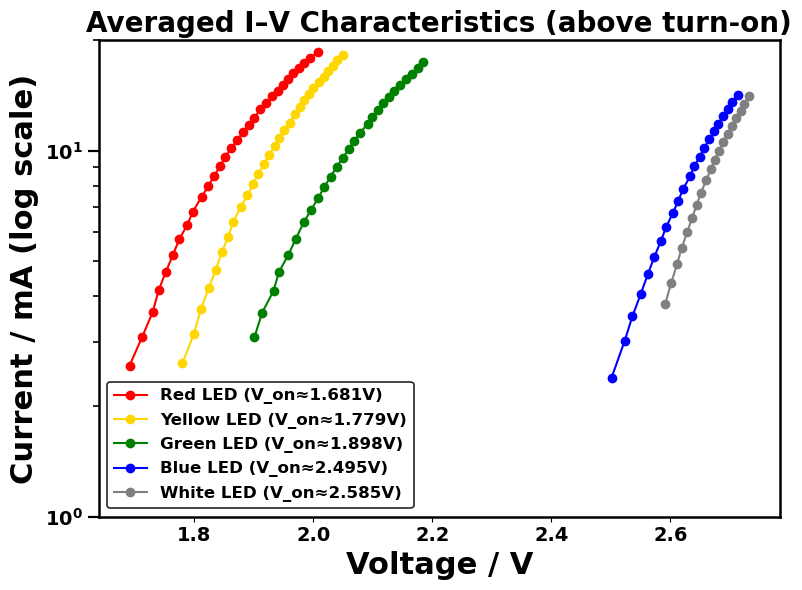

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Averaged I–V (semi-log, trimmed).png


In [243]:
#note: semi-log scale I-V plot of LEDs

df_rt = pd.read_csv(error_bar_datapath)
V_on = {led: df_rt[cols[led]].dropna().astype(float).mean() for led in full_labels}

fig, ax = init_ax(figsize=(8, 6))

for led in full_labels:
    V, I = load_iv_from_csv(paths[led], V_col=0, I_col=6)

    m = (I > 0) & (V >= (V_on[led]))
    ax.semilogy(
        V[m], I[m], "o-",
        color=colors[led],
        label=f"{led} (V_on≈{V_on[led]:.3f}V)"
    )

ax.tick_params(axis="y", which="major", length=8, width=1.6)
ax.tick_params(axis="y", which="minor", length=4, width=1.2)
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(NullFormatter())

out_path = fig_path("Averaged I–V (semi-log, trimmed).png")
finalize_plot(
    ax,
    xlabel="Voltage / V",
    ylabel="Current / mA (log scale)",
    title="Averaged I–V Characteristics (above turn-on)",
    out_path=out_path,
    legend=True,
    legend_loc="lower left",
    legend_size=12,
    ylim=(1,20)
    
)
print(f"Saved figure → {out_path}")

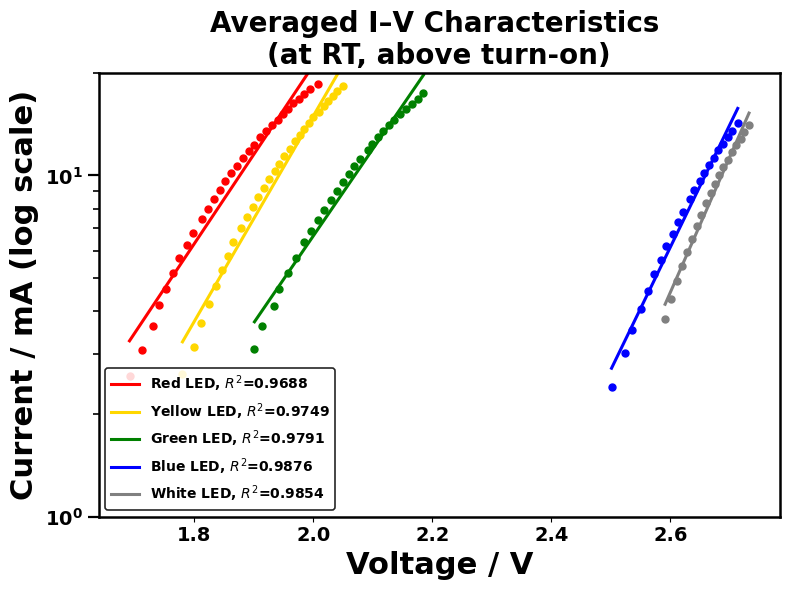

RT slope list (dec/V): [2.61514, 3.01107, 2.54636, 3.59099, 3.97275]
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Averaged I–V (semi-log, trimmed) with fits.png


In [244]:
#note: semi-log scale I-V plot of LEDs with linear fit

out_path = fig_path("Averaged I–V (semi-log, trimmed) with fits.png")

slope_list_rt = plot_semilog_iv_with_fit(
    labels=full_labels,
    path_map=paths,
    V_on_map=V_on,
    loader=lambda p: load_iv_from_csv(p, V_col=0, I_col=6),
    title="Averaged I–V Characteristics \n(at RT, above turn-on)",
    out_path=out_path,
    ylim=(1, 20),
    legend_loc="lower left",
    legend_size=10
)

print("RT slope list (dec/V):", slope_list_rt)
print(f"Saved figure → {out_path}")

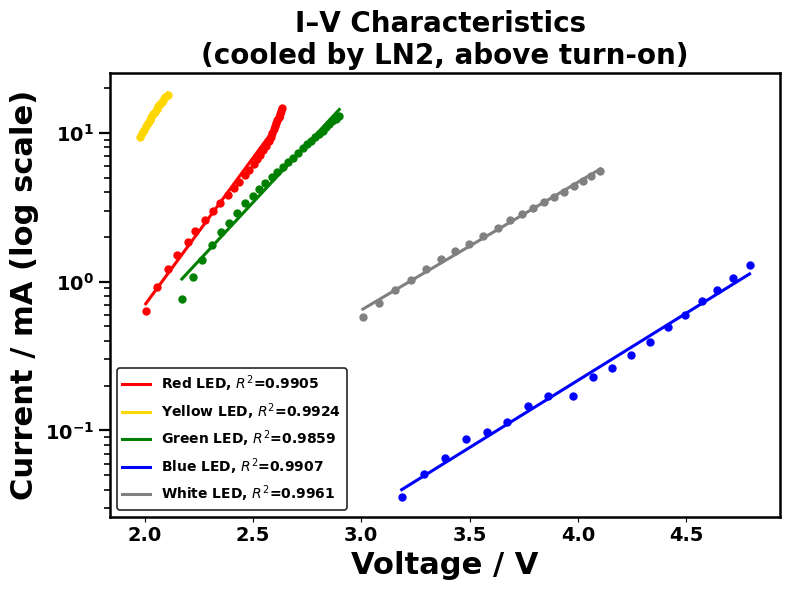

LN2 slope list (dec/V): [1.97967, 2.24007, 1.56792, 0.90316, 0.85926]
Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/LN2-cooled I–V (semi-log, trimmed) with fits.png


In [245]:
# note: semi-log I–V plot of LN2-cooled LEDs with linear fit

V_on_ln2 = {
    "Red LED": 2.005, "Yellow LED": 1.979, "Green LED": 2.172,
    "Blue LED": 3.186, "White LED": 3.007,
}

out_path = fig_path("LN2-cooled I–V (semi-log, trimmed) with fits.png")

slope_list_ln2 = plot_semilog_iv_with_fit(
    labels=full_labels,
    path_map=ln2_paths,
    V_on_map=V_on_ln2,
    loader=load_ln2_iv_csv,
    title="I–V Characteristics \n(cooled by LN2, above turn-on)",
    out_path=out_path,
    legend_loc="lower left",
    legend_size=10
)

print("LN2 slope list (dec/V):", slope_list_ln2)
print(f"Saved figure → {out_path}")

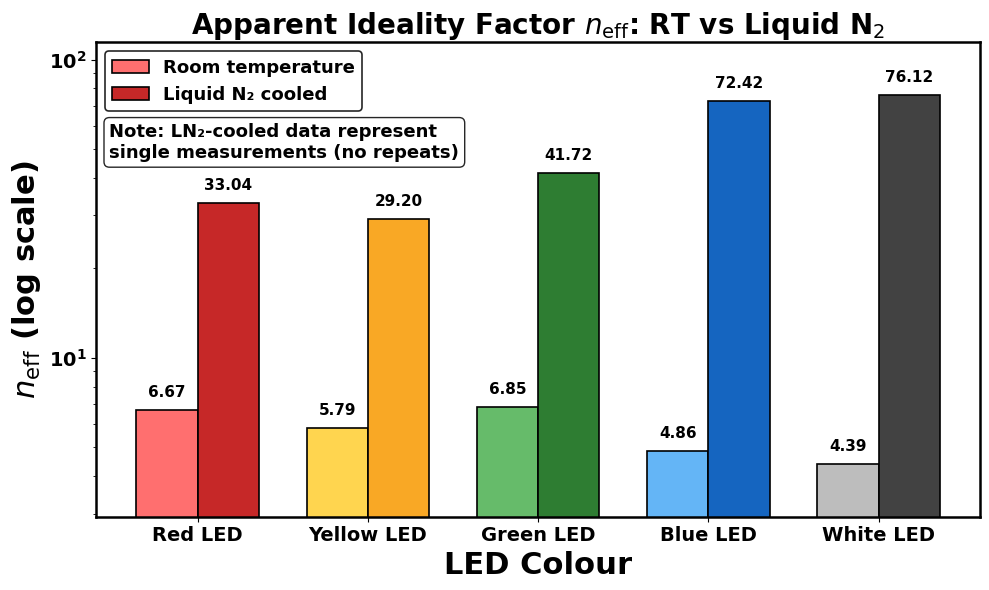

Saved figure → /Users/liangze/Desktop/26 Spring/Practical Chemistry/Introduction to computer controlled experiments/ICCE 20260124/Figures/Apparent_ideality_factor_RT_vs_LN2.png


In [246]:
#note: barplot of "apparent" ideality factor of LEDs at rt and cooled by LN2. 

labels = full_labels
rt_n = np.asarray(rt_n_calculator(slope_list_rt), dtype=float)
ln2_n = np.asarray(ln2_n_calculator(slope_list_ln2), dtype=float)

out_path = fig_path("Apparent_ideality_factor_RT_vs_LN2.png")
grouped_barplot_two_conditions(
    labels,
    rt_n, ln2_n,
    colors1=colors_for(labels, colors_rt),
    colors2=colors_for(labels, colors_ln2),
    label1="Room temperature",
    label2="Liquid N₂ cooled",
    xlabel="LED Colour",
    ylabel=r"$n_{\mathrm{eff}}$ (log scale)",
    title=r"Apparent Ideality Factor $n_{\mathrm{eff}}$: RT vs Liquid N$_2$",
    note="Note: LN₂-cooled data represent\nsingle measurements (no repeats)",
    annotate_fmt="{:.2f}",
    logy=True,   
    grid_alpha=0,    
    out_path=out_path
)
print(f"Saved figure → {out_path}")